# Part 1: Decision Trees and the Risk of Overfitting

In this lesson, we will explore **Decision Trees**, a powerful family of algorithms used for both classification and regression. Decision Trees work by repeatedly splitting the data based on feature values to create 'leaves' of similar data points.

### 1. Loading the Iris Dataset
We will use the classic **Iris Dataset**. It contains 150 samples of iris flowers from three different species:
- **Setosa**
- **Versicolor**
- **Virginica**

Each sample has four features (dimensions in cm):
1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Convert to DataFrame for a quick look at the features
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 2. The Train-Test Split
To know if our model actually 'learned' or just 'memorized' the data, we must hide some data during training. We split our data into:
- **Training Set**: Used to build the tree.
- **Testing Set**: Used to evaluate the model on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data: 67% for training and 33% for testing
# Fixed: changed 'random_name' to 'random_state'
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 100
Testing samples: 50


### 3. Building the Fully Grown Tree (The Problem)
By default, a `DecisionTreeClassifier` will continue splitting nodes until every 'leaf' is pure (Gini impurity = 0). While this gets 100% accuracy on the training data, it often creates a massive, complex tree that fails to generalize to new data. This is called **Overfitting**.

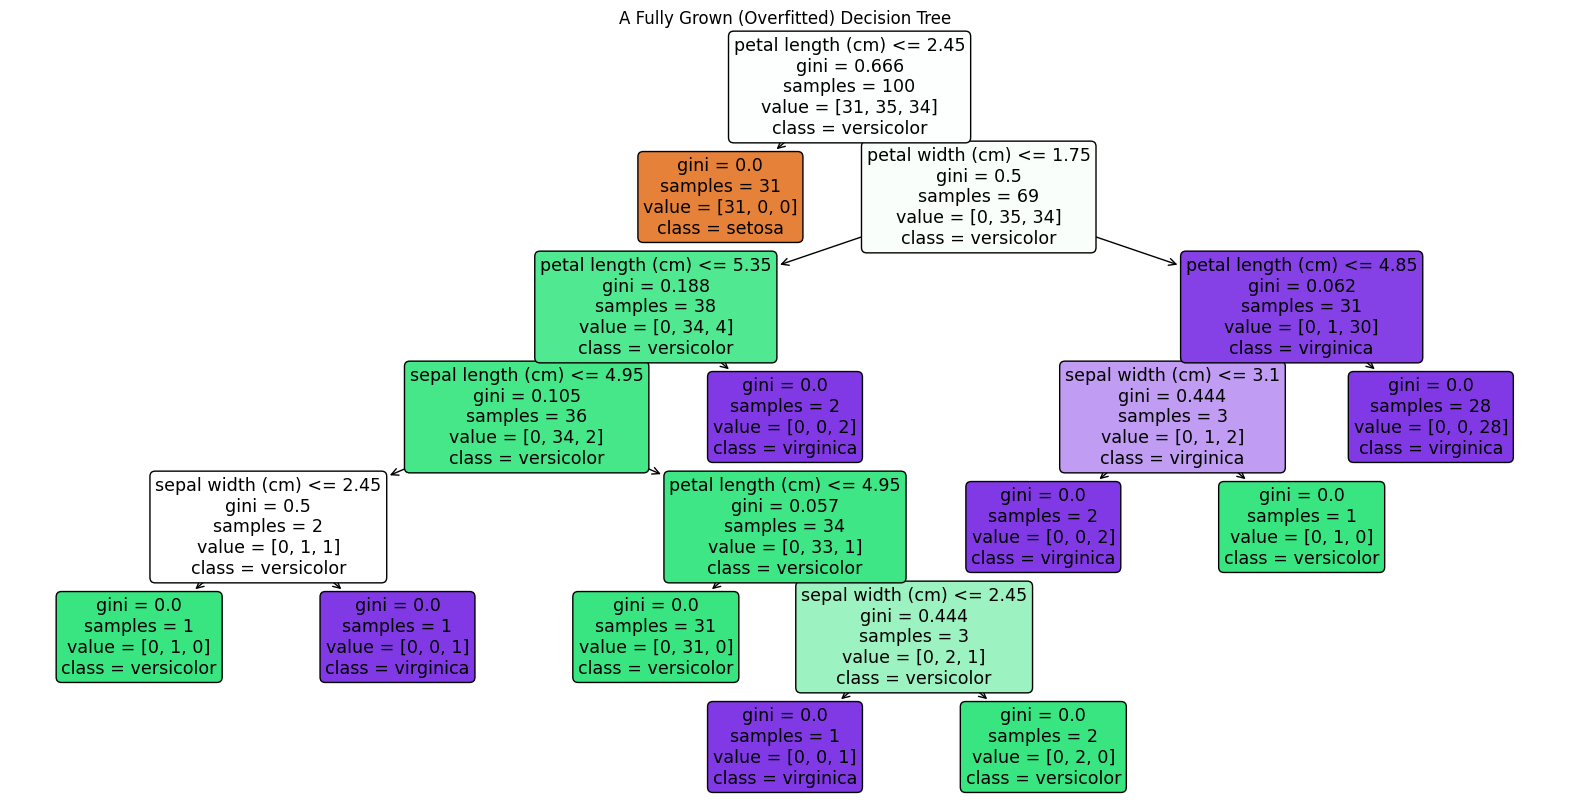

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Initialize the model with NO constraints (fully grown)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Visualize the resulting complex tree
plt.figure(figsize=(20,10))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True)

plt.title("A Fully Grown (Overfitted) Decision Tree")
plt.show()

# New Scenario: The Play Tennis Dataset
In this example, we predict whether to play tennis based on weather conditions. This dataset is famous for demonstrating how Decision Trees handle categorical data.

# Part 2: Analyzing the Tree and Applying Post-Pruning

### 1. Analyzing the Fully Grown Tree
If you look at the visualization in Part 1, you'll notice nodes at the bottom that split just to separate a single outlier. This makes the model very sensitive to 'noise' in the training data.

**Post-Pruning** is the process of taking a fully grown (and likely overfitted) tree and 'trimming' it back. By restricting how deep the tree can go, we force it to focus on the most important patterns rather than memorizing every single data point.

### 2. Applying Post-Pruning (`max_depth`)
The simplest way to prune a tree is by setting the `max_depth` hyperparameter. This tells the algorithm: "You can only split the data a maximum of $N$ times."

When a node stops splitting before it is perfectly 'pure' (Gini > 0), it uses **Majority Voting**. For example, if a leaf node contains 30 *Versicolor* and 2 *Virginica* samples, it will simply predict *Versicolor* for any new data that falls into that leaf.

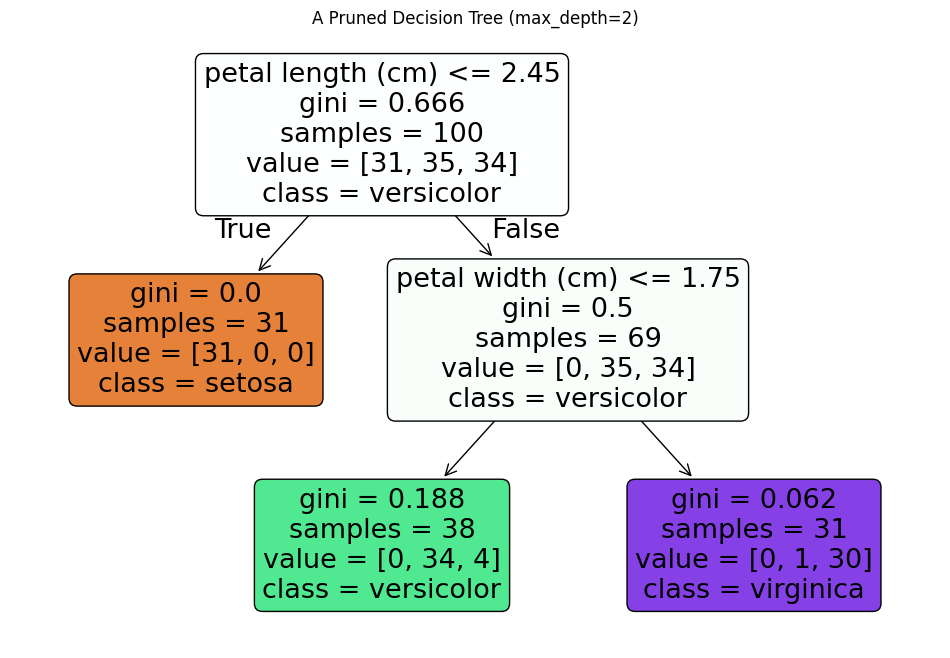

In [ ]:
# Re-initialize the model with a depth constraint
# We set max_depth=2 to keep the tree simple and interpretable
pruned_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
pruned_clf.fit(X_train, y_train)

# Visualize the pruned tree
plt.figure(figsize=(12,8))
plot_tree(pruned_clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True)

plt.title("A Pruned Decision Tree (max_depth=2)")
plt.show()

### Contrast and Compare
Notice the difference:
1. **Complexity**: The first tree had many levels and was hard to read. This pruned tree is clean and easy to explain to a human.
2. **Generalization**: While the first tree had 100% accuracy on the training data, this simpler tree is often more robust and performs better on the **Testing Set** because it hasn't 'over-fit' to the training noise.

# Part 3: Model Prediction and Evaluation

### 1. Making Predictions
Now that our model is trained and pruned, we test it using the **Testing Set** (`X_test`). This data was hidden from the model during training, so its performance here tells us how well it generalizes to the real world.

We use the `.predict()` method to get the model's 'guesses' for the flower species.

In [ ]:
# Use the pruned model to make predictions on the unseen test data
y_pred = pruned_clf.predict(X_test)

print("Predictions generated for the test set.")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual labels: {y_test[:10]}")

Predictions generated for the test set.
First 10 predictions: [1 0 2 1 1 0 1 2 1 1]
First 10 actual labels: [1 0 2 1 1 0 1 2 1 1]


### 2. Evaluating the Pruned Model
To measure success, we compare the model's predictions (`y_pred`) against the actual known labels (`y_test`). We use two main tools:
- **Accuracy Score**: The percentage of total predictions that were correct.
- **Classification Report**: A detailed breakdown showing Precision, Recall, and F1-Score for each species.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Model Accuracy: 98.00%

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



### Interpreting the Results
An accuracy score (for example, 98%) means the model successfully generalized from the training data to the testing data. Because we pruned the tree, it didn't get 'distracted' by noise and instead learned the fundamental rules of the Iris species.

**Congratulations!** You have successfully built, visualized, pruned, and evaluated a Decision Tree Classifier. In real-world scenarios, you will use Hyperparameter Tuning (Pre-pruning) to find the best depth automatically, which we will cover next!

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 1. Create the dataset
data = {
    'Weather': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df_tennis = pd.DataFrame(data)

# 2. Encode categorical strings into numbers
le = LabelEncoder()
for col in df_tennis.columns:
    df_tennis[col] = le.fit_transform(df_tennis[col])

X_tennis = df_tennis[['Weather', 'Temp', 'Humidity', 'Wind']]
y_tennis = df_tennis['Play']

display(df_tennis.head())

,Weather,Temp,Humidity,Wind,Play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


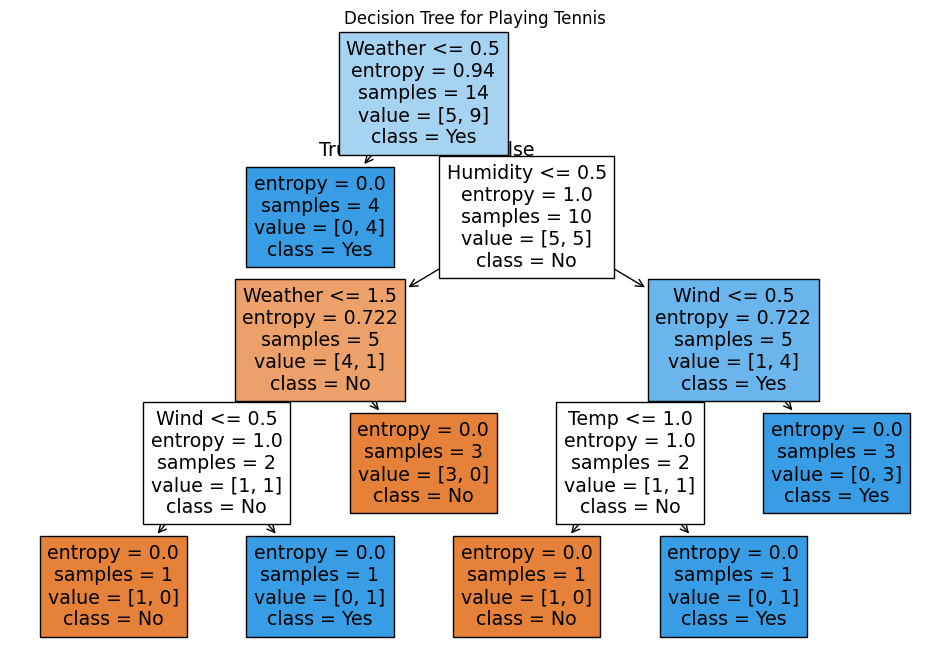

In [ ]:
# 3. Build and Visualize the Tree
clf_tennis = DecisionTreeClassifier(criterion='entropy')
clf_tennis.fit(X_tennis, y_tennis)

plt.figure(figsize=(12,8))
plot_tree(clf_tennis,
          feature_names=['Weather', 'Temp', 'Humidity', 'Wind'],
          class_names=['No', 'Yes'],
          filled=True)
plt.title("Decision Tree for Playing Tennis")
plt.show()

### Why use Text Representation?
- **Readability**: It clearly shows the threshold values used for every split (e.g., `petal width (cm) <= 0.80`).
- **Logic Flow**: You can trace the path of a single data point step-by-step through the indentations.
- **No Scaling Issues**: Unlike images, text scales perfectly regardless of how many branches the tree has.